<a href="https://colab.research.google.com/github/Shambhuraje1919/Machine_Learning_Paractice/blob/main/THE_INDIAN_FRESHER_JOB_MARKET_WHO_GETS_HIRED.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
shambhurajejagadale_indian_fresher_job_market_who_gets_hired_and_why_path = kagglehub.dataset_download('shambhurajejagadale/indian-fresher-job-market-who-gets-hired-and-why')

print('Data source import complete.')


✅  Libraries loaded & plot style configured.

▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  THE INDIAN FRESHER JOB MARKET: WHO GETS HIRED & WHY?
▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓

✅  Dataset loaded  →  5,000 rows × 30 columns

════════════════════════════════════════════════════════════
  📊  DATASET OVERVIEW
════════════════════════════════════════════════════════════
  Rows       : 5,000
  Columns    : 30
  Memory     : 5319.9 KB
  Date range : 2021-01-01  →  2024-12-31

  ⚠️   Missing values:
interview_rounds      3182
offered_salary_inr    4378
linkedin_premium      3901

────────────────────────────────────────────────────────────
candidate_id                       int64
full_name                         object
gender                            object
age                                int64
graduation_year                    int64
college                           object
degree                            object
branch                    

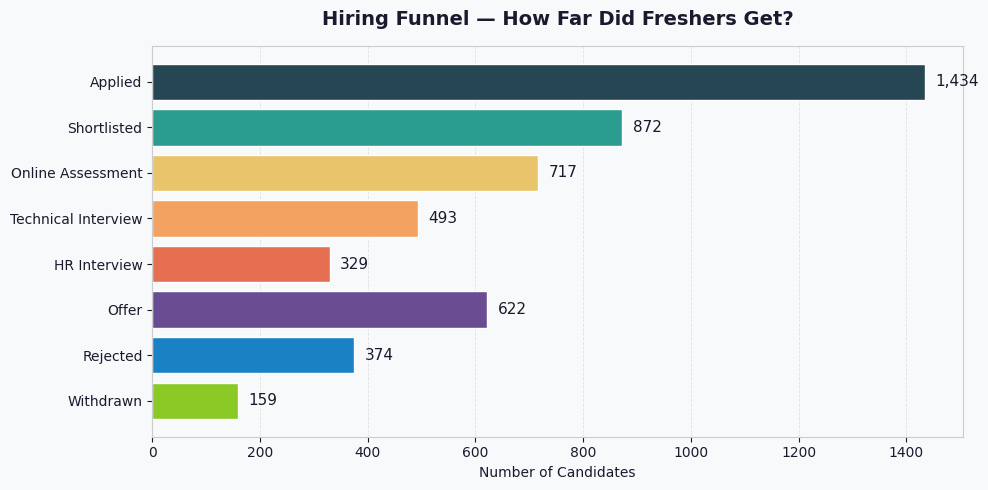

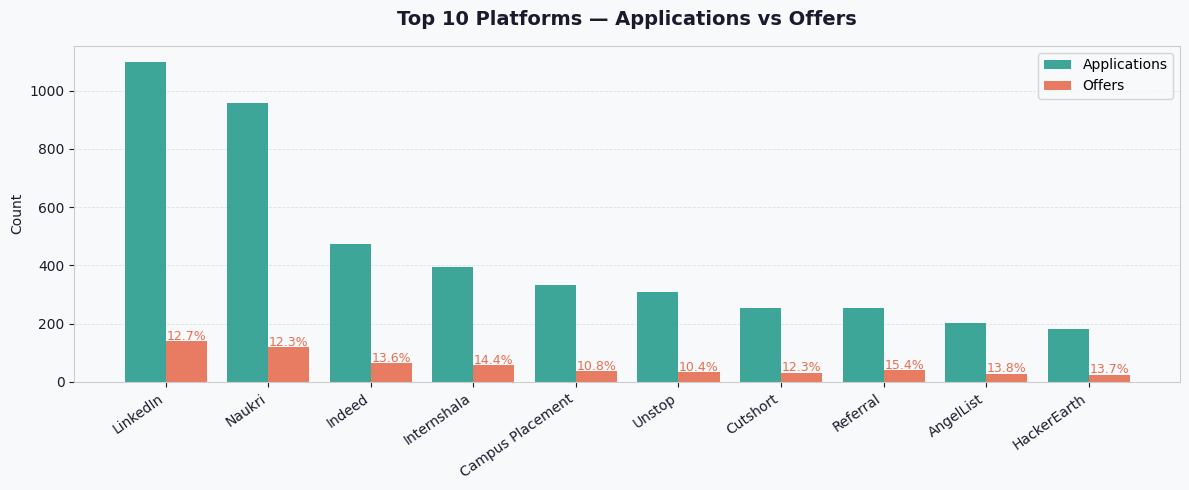

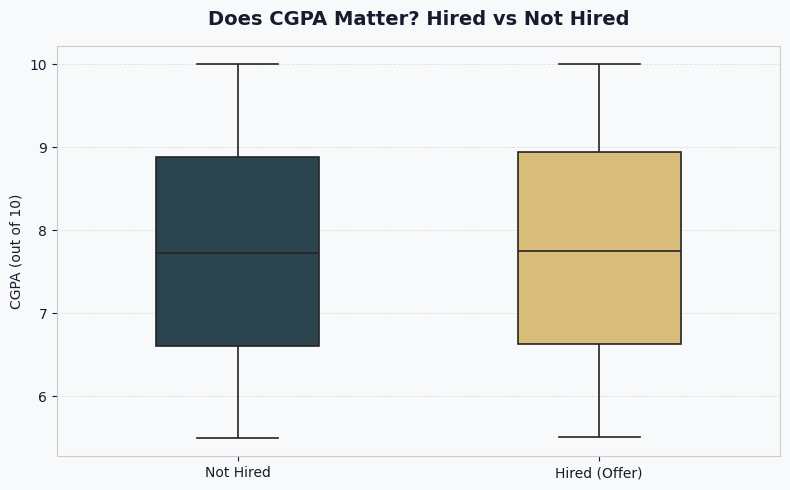

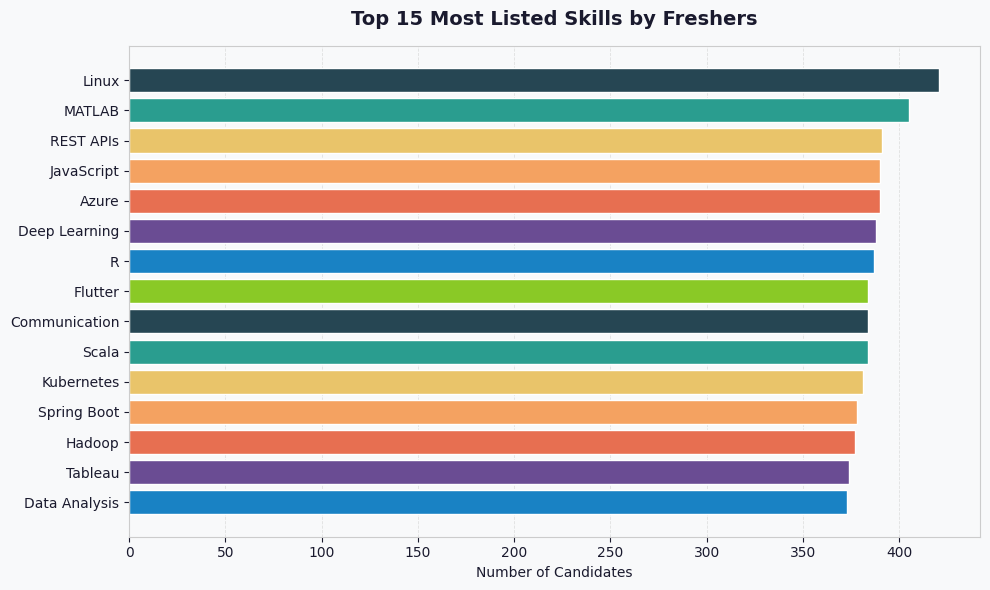

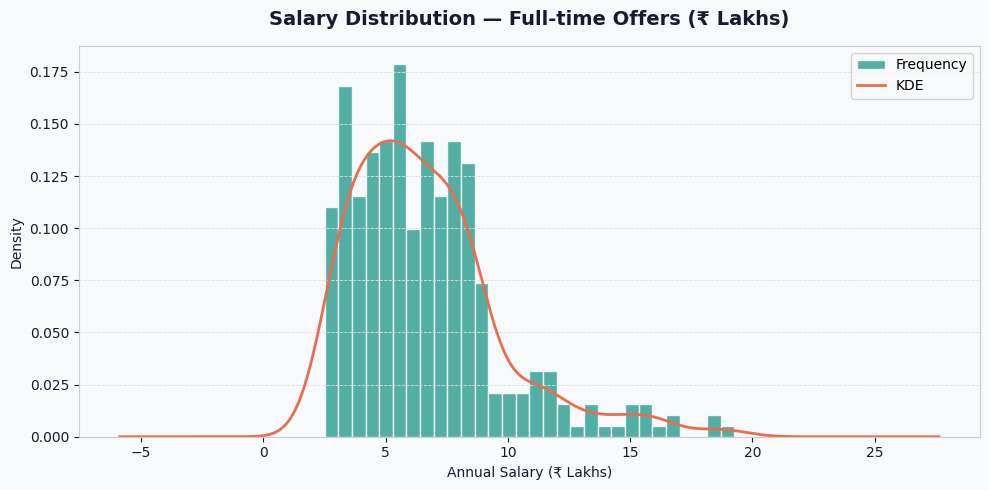


  💰  Salary Statistics (Full-time Offers)
      Median  : ₹6.07 L
      Mean    : ₹6.64 L
      Min     : ₹2.51 L
      Max     : ₹19.26 L
      Std Dev : ₹3.08 L



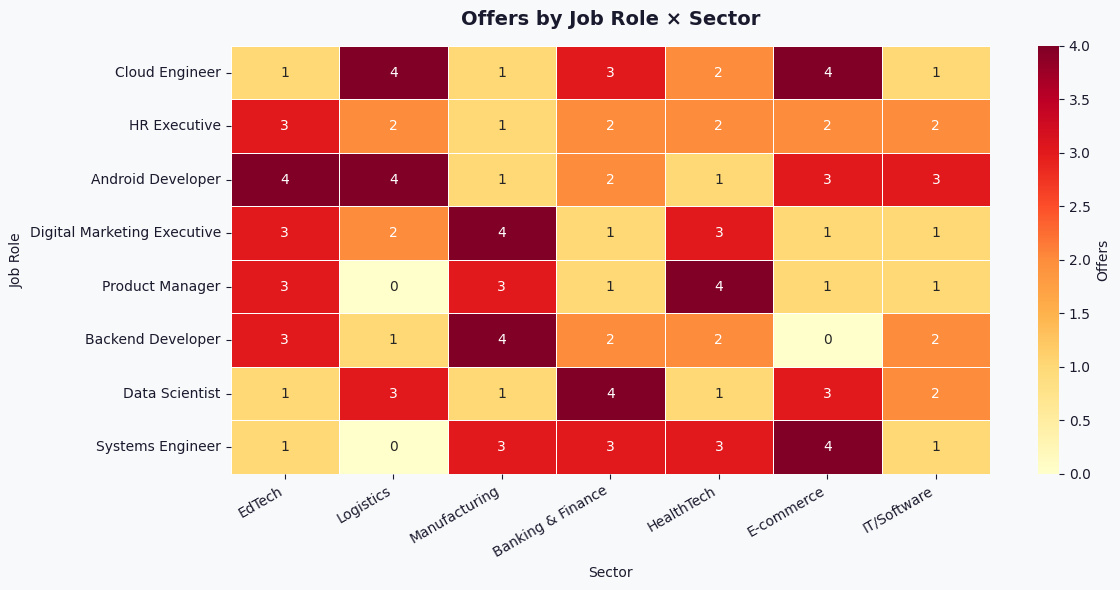

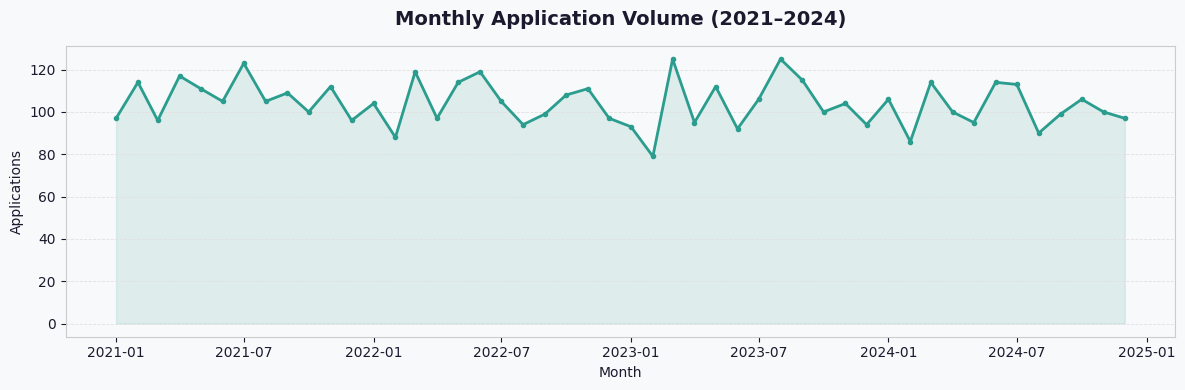


✅  Full analysis complete. DataFrame returned for further exploration.



In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║         THE INDIAN FRESHER JOB MARKET: WHO GETS HIRED & WHY?               ║
# ║         Synthetic Dataset — 5,000 Records | 2021–2024                      ║
# ║         Author  : Shambhuraje                                             ║
# ║         Platform: Kaggle Notebook                                           ║
# ║         Dataset : indian-fresher-hiring-dataset-2021-2024                  ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# ─────────────────────────────────────────────────────────────────────────────
# 📦  SECTION 1 — IMPORTS & GLOBAL CONFIG
# ─────────────────────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
from collections import Counter

warnings.filterwarnings("ignore")

# ── Plotting style ────────────────────────────────────────────────────────────
PALETTE   = ["#264653","#2A9D8F","#E9C46A","#F4A261","#E76F51","#6A4C93","#1982C4","#8AC926"]
BG_COLOR  = "#F8F9FA"
TEXT_COLOR = "#1A1A2E"

plt.rcParams.update({
    "figure.facecolor"  : BG_COLOR,
    "axes.facecolor"    : BG_COLOR,
    "axes.edgecolor"    : "#CCCCCC",
    "axes.labelcolor"   : TEXT_COLOR,
    "axes.titlesize"    : 14,
    "axes.titleweight"  : "bold",
    "axes.titlecolor"   : TEXT_COLOR,
    "xtick.color"       : TEXT_COLOR,
    "ytick.color"       : TEXT_COLOR,
    "font.family"       : "DejaVu Sans",
    "grid.color"        : "#E0E0E0",
    "grid.linestyle"    : "--",
    "grid.linewidth"    : 0.6,
})

print("✅  Libraries loaded & plot style configured.")


# ─────────────────────────────────────────────────────────────────────────────
# 📂  SECTION 2 — LOAD & FIRST LOOK AT THE DATASET
# ─────────────────────────────────────────────────────────────────────────────

def load_data(filepath: str) -> pd.DataFrame:
    """
    Load the CSV dataset and return a DataFrame.
    Handles encoding and parses application_date as datetime.
    """
    df = pd.read_csv("/kaggle/input/datasets/shambhurajejagadale/indian-fresher-job-market-who-gets-hired-and-why/fresher_hiring_india_dataset.csv", parse_dates=["application_date"], encoding="utf-8")
    print(f"✅  Dataset loaded  →  {df.shape[0]:,} rows × {df.shape[1]} columns")
    return df


def quick_overview(df: pd.DataFrame) -> None:
    """
    Print a compact overview: shape, dtypes, missing values, and basic stats.
    """
    print("\n" + "═"*60)
    print("  📊  DATASET OVERVIEW")
    print("═"*60)
    print(f"  Rows       : {df.shape[0]:,}")
    print(f"  Columns    : {df.shape[1]}")
    print(f"  Memory     : {df.memory_usage(deep=True).sum() / 1024:.1f} KB")
    print(f"  Date range : {df['application_date'].min().date()}  →  {df['application_date'].max().date()}")

    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if missing.empty:
        print("\n  ✅  No missing values found (except expected blanks in salary/rounds).")
    else:
        print(f"\n  ⚠️   Missing values:\n{missing.to_string()}")

    print("\n" + "─"*60)
    print(df.dtypes.to_string())
    print("═"*60 + "\n")


# ─────────────────────────────────────────────────────────────────────────────
# 🔧  SECTION 3 — DATA CLEANING & FEATURE ENGINEERING
# ─────────────────────────────────────────────────────────────────────────────

def clean_and_engineer(df: pd.DataFrame) -> pd.DataFrame:
    """
    Clean the dataset and add derived features:
      - hired            : binary target (1 = Offer, 0 = otherwise)
      - app_month        : month of application (1–12)
      - app_year         : year of application
      - skills_count     : number of skills listed
      - exp_level        : experience proxy from prior_internship + projects
      - salary_lakhs     : offered salary converted to lakhs (INR)
      - cgpa_band        : CGPA bucketed into grade bands
      - platform_type    : groups platforms into Online / Campus / Referral
    """
    df = df.copy()

    # ── Target variable ───────────────────────────────────────────────────────
    df["hired"] = (df["hiring_stage"] == "Offer").astype(int)

    # ── Date features ─────────────────────────────────────────────────────────
    df["app_month"] = df["application_date"].dt.month
    df["app_year"]  = df["application_date"].dt.year

    # ── Skills count from pipe-separated string ───────────────────────────────
    df["skills_count"] = df["top_skills"].str.split("|").apply(
        lambda x: len([s.strip() for s in x if s.strip()]) if isinstance(x, list) else 0
    )

    # ── Experience proxy: 0 = no internship + no projects, 2 = both ──────────
    df["exp_level"] = (
        (df["prior_internship"] == "Yes").astype(int) +
        (df["projects_count"] >= 2).astype(int)
    )

    # ── Salary in lakhs (only where offered) ─────────────────────────────────
    df["salary_lakhs"] = pd.to_numeric(df["offered_salary_inr"], errors="coerce") / 100_000

    # ── CGPA bands ────────────────────────────────────────────────────────────
    df["cgpa_band"] = pd.cut(
        df["cgpa"],
        bins   = [0, 6.0, 7.0, 8.0, 9.0, 10.01],
        labels = ["<6.0", "6–7", "7–8", "8–9", "9–10"],
        right  = False
    )

    # ── Platform type grouping ────────────────────────────────────────────────
    campus_platforms  = ["Campus Placement"]
    referral_platforms = ["Referral"]
    def classify_platform(p):
        if p in campus_platforms:  return "Campus"
        if p in referral_platforms: return "Referral"
        return "Online"
    df["platform_type"] = df["platform"].apply(classify_platform)

    print("✅  Cleaning & feature engineering complete.")
    print(f"    New columns added: hired, app_month, app_year, skills_count,")
    print(f"                       exp_level, salary_lakhs, cgpa_band, platform_type")
    return df


# ─────────────────────────────────────────────────────────────────────────────
# 📈  SECTION 4 — EXPLORATORY DATA ANALYSIS (EDA)
# ─────────────────────────────────────────────────────────────────────────────

def plot_hiring_funnel(df: pd.DataFrame) -> None:
    """
    Horizontal bar chart showing count of candidates at each hiring stage.
    Ordered from earliest to furthest stage in the funnel.
    """
    order  = ["Applied","Shortlisted","Online Assessment",
              "Technical Interview","HR Interview","Offer","Rejected","Withdrawn"]
    counts = df["hiring_stage"].value_counts().reindex(order).fillna(0)

    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.barh(counts.index, counts.values, color=PALETTE[:len(order)], edgecolor="white")

    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
                f"{int(val):,}", va="center", fontsize=11, color=TEXT_COLOR)

    ax.set_title("Hiring Funnel — How Far Did Freshers Get?", pad=15)
    ax.set_xlabel("Number of Candidates")
    ax.invert_yaxis()
    ax.grid(axis="x")
    ax.set_axisbelow(True)
    plt.tight_layout()
    plt.show()


def plot_platform_performance(df: pd.DataFrame, top_n: int = 10) -> None:
    """
    Grouped bar chart: application count vs offer count per platform.
    Shows which platforms convert applications to offers most effectively.
    """
    stats = (
        df.groupby("platform")
          .agg(applications=("hired","count"), offers=("hired","sum"))
          .sort_values("applications", ascending=False)
          .head(top_n)
    )
    stats["offer_rate"] = (stats["offers"] / stats["applications"] * 100).round(1)

    x  = np.arange(len(stats))
    w  = 0.4
    fig, ax = plt.subplots(figsize=(12, 5))

    ax.bar(x - w/2, stats["applications"], width=w, label="Applications", color=PALETTE[1], alpha=0.9)
    ax.bar(x + w/2, stats["offers"],       width=w, label="Offers",       color=PALETTE[4], alpha=0.9)

    ax.set_xticks(x)
    ax.set_xticklabels(stats.index, rotation=35, ha="right", fontsize=10)
    ax.set_title(f"Top {top_n} Platforms — Applications vs Offers", pad=15)
    ax.set_ylabel("Count")
    ax.legend()
    ax.grid(axis="y")
    ax.set_axisbelow(True)

    # ── Offer rate label on top of each offer bar ──────────────────────────
    for i, (rate, offers) in enumerate(zip(stats["offer_rate"], stats["offers"])):
        ax.text(i + w/2, offers + 5, f"{rate}%", ha="center", fontsize=9, color=PALETTE[4])

    plt.tight_layout()
    plt.show()


def plot_cgpa_vs_hiring(df: pd.DataFrame) -> None:
    """
    Box plot comparing CGPA distribution for hired vs not-hired candidates.
    Answers: does CGPA actually matter?
    """
    fig, ax = plt.subplots(figsize=(8, 5))
    hired_map = {0: "Not Hired", 1: "Hired (Offer)"}
    df["hired_label"] = df["hired"].map(hired_map)

    sns.boxplot(
        data    = df,
        x       = "hired_label",
        y       = "cgpa",
        palette = [PALETTE[0], PALETTE[2]],
        width   = 0.45,
        linewidth = 1.2,
        ax      = ax
    )
    ax.set_title("Does CGPA Matter? Hired vs Not Hired", pad=15)
    ax.set_xlabel("")
    ax.set_ylabel("CGPA (out of 10)")
    ax.grid(axis="y")
    plt.tight_layout()
    plt.show()


def plot_top_skills(df: pd.DataFrame, top_n: int = 15) -> None:
    """
    Horizontal bar chart of the most commonly listed skills across all candidates.
    """
    all_skills = []
    for entry in df["top_skills"].dropna():
        all_skills.extend([s.strip() for s in entry.split("|") if s.strip()])

    skill_counts = Counter(all_skills).most_common(top_n)
    skills, counts = zip(*skill_counts)

    fig, ax = plt.subplots(figsize=(10, 6))
    colors  = [PALETTE[i % len(PALETTE)] for i in range(top_n)]
    ax.barh(skills[::-1], counts[::-1], color=colors[::-1], edgecolor="white")
    ax.set_title(f"Top {top_n} Most Listed Skills by Freshers", pad=15)
    ax.set_xlabel("Number of Candidates")
    ax.grid(axis="x")
    ax.set_axisbelow(True)
    plt.tight_layout()
    plt.show()


def plot_salary_distribution(df: pd.DataFrame) -> None:
    """
    KDE + histogram of offered salaries (in lakhs) for full-time roles.
    Also prints key salary statistics.
    """
    salary_df = df[(df["salary_lakhs"].notna()) & (df["work_type"] == "Full-time")]

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(salary_df["salary_lakhs"], bins=30, color=PALETTE[1],
            edgecolor="white", alpha=0.8, density=True, label="Frequency")

    salary_df["salary_lakhs"].plot.kde(ax=ax, color=PALETTE[4], linewidth=2, label="KDE")

    ax.set_title("Salary Distribution — Full-time Offers (₹ Lakhs)", pad=15)
    ax.set_xlabel("Annual Salary (₹ Lakhs)")
    ax.set_ylabel("Density")
    ax.legend()
    ax.grid(axis="y")
    plt.tight_layout()
    plt.show()

    print("\n  💰  Salary Statistics (Full-time Offers)")
    print(f"      Median  : ₹{salary_df['salary_lakhs'].median():.2f} L")
    print(f"      Mean    : ₹{salary_df['salary_lakhs'].mean():.2f} L")
    print(f"      Min     : ₹{salary_df['salary_lakhs'].min():.2f} L")
    print(f"      Max     : ₹{salary_df['salary_lakhs'].max():.2f} L")
    print(f"      Std Dev : ₹{salary_df['salary_lakhs'].std():.2f} L\n")


def plot_heatmap_role_sector(df: pd.DataFrame, top_roles: int = 8, top_sectors: int = 7) -> None:
    """
    Heatmap showing offer counts across top job roles and sectors.
    Reveals which role–sector combinations have the most offers.
    """
    offers = df[df["hired"] == 1]
    pivot  = (
        offers.groupby(["job_role", "sector"])
              .size()
              .unstack(fill_value=0)
    )
    top_r = pivot.sum(axis=1).nlargest(top_roles).index
    top_s = pivot.sum(axis=0).nlargest(top_sectors).index
    pivot = pivot.loc[top_r, top_s]

    fig, ax = plt.subplots(figsize=(12, 6))
    sns.heatmap(
        pivot,
        annot      = True,
        fmt        = "d",
        cmap       = "YlOrRd",
        linewidths = 0.5,
        linecolor  = "white",
        ax         = ax,
        cbar_kws   = {"label": "Offers"}
    )
    ax.set_title("Offers by Job Role × Sector", pad=15)
    ax.set_xlabel("Sector")
    ax.set_ylabel("Job Role")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()


def plot_applications_over_time(df: pd.DataFrame) -> None:
    """
    Line chart showing monthly application volume over the 2021–2024 period.
    """
    monthly = (
        df.groupby(df["application_date"].dt.to_period("M"))
          .size()
          .reset_index(name="count")
    )
    monthly["application_date"] = monthly["application_date"].dt.to_timestamp()

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(monthly["application_date"], monthly["count"],
            color=PALETTE[1], linewidth=2, marker="o", markersize=3)
    ax.fill_between(monthly["application_date"], monthly["count"],
                    alpha=0.12, color=PALETTE[1])
    ax.set_title("Monthly Application Volume (2021–2024)", pad=15)
    ax.set_xlabel("Month")
    ax.set_ylabel("Applications")
    ax.grid(axis="y")
    plt.tight_layout()
    plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# 📊  SECTION 5 — SUMMARY STATISTICS
# ─────────────────────────────────────────────────────────────────────────────

def print_summary_stats(df: pd.DataFrame) -> None:
    """
    Print a clean summary of key metrics from the dataset.
    """
    total        = len(df)
    hired        = df["hired"].sum()
    offer_rate   = hired / total * 100
    avg_cgpa     = df["cgpa"].mean()
    avg_resp     = df["response_time_days"].mean()
    top_platform = df["platform"].value_counts().idxmax()
    top_role     = df["job_role"].value_counts().idxmax()
    top_company  = df["company_applied"].value_counts().idxmax()
    top_location = df["job_location"].value_counts().idxmax()

    print("\n" + "═"*60)
    print("  🔑  KEY METRICS AT A GLANCE")
    print("═"*60)
    print(f"  Total applications    : {total:,}")
    print(f"  Total offers          : {hired:,}  ({offer_rate:.1f}%)")
    print(f"  Average CGPA          : {avg_cgpa:.2f}")
    print(f"  Avg response time     : {avg_resp:.1f} days")
    print(f"  Most used platform    : {top_platform}")
    print(f"  Most applied role     : {top_role}")
    print(f"  Most applied company  : {top_company}")
    print(f"  Top job location      : {top_location}")
    print("═"*60 + "\n")


# ─────────────────────────────────────────────────────────────────────────────
# 🚀  SECTION 6 — MAIN PIPELINE  (run everything)
# ─────────────────────────────────────────────────────────────────────────────

def run_full_analysis(filepath: str) -> pd.DataFrame:
    """
    Master pipeline: load → clean → EDA → summary.
    Returns the cleaned & feature-engineered DataFrame for further use.

    Usage:
        df = run_full_analysis("/kaggle/input/indian-fresher-hiring-dataset/fresher_hiring_india_dataset.csv")
    """
    print("\n" + "▓"*60)
    print("  THE INDIAN FRESHER JOB MARKET: WHO GETS HIRED & WHY?")
    print("▓"*60 + "\n")

    # ── Step 1: Load ──────────────────────────────────────────────────────────
    df = load_data(filepath)

    # ── Step 2: Overview ──────────────────────────────────────────────────────
    quick_overview(df)

    # ── Step 3: Clean & engineer features ────────────────────────────────────
    df = clean_and_engineer(df)

    # ── Step 4: Key metrics ───────────────────────────────────────────────────
    print_summary_stats(df)

    # ── Step 5: Visualisations ────────────────────────────────────────────────
    print("📊  Generating plots...\n")
    plot_hiring_funnel(df)
    plot_platform_performance(df, top_n=10)
    plot_cgpa_vs_hiring(df)
    plot_top_skills(df, top_n=15)
    plot_salary_distribution(df)
    plot_heatmap_role_sector(df)
    plot_applications_over_time(df)

    print("\n✅  Full analysis complete. DataFrame returned for further exploration.\n")
    return df


# ─────────────────────────────────────────────────────────────────────────────
# ▶  ENTRY POINT — change the path to match your Kaggle input folder
# ─────────────────────────────────────────────────────────────────────────────

if __name__ == "__main__":
    FILE_PATH = "/kaggle/input/datasets/shambhurajejagadale/indian-fresher-job-market-who-gets-hired-and-why/fresher_hiring_india_dataset.csv"
    df = run_full_analysis(FILE_PATH)



# ══════════════════════════════════════════════════════════════════════════════
#  End of notebook  |  Happy exploring! 🎓
# ══════════════════════════════════════════════════════════════════════════════